In [45]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

from openai import OpenAI

In [46]:
LLM_MODEL = "gpt-5.4-mini"
load_dotenv()

True

In [47]:
class LLM():
    def __init__(self, model):
        self.model = model
        self.client = None

    def instantiate_llm(self):
        return OpenAI()

    def invoke_summarization(self, text):
        if self.client is None:
            self.client = self.instantiate_llm()

        response = self.client.responses.create(
            model=self.model,
            instructions="Summarize the given text into a brief 1-2 lines",
            input= f"Summarize this text:\n{text}",
        )

        return response.output_text

In [48]:
class State(TypedDict):
    text: str
    summary: str 

In [49]:
def extract(state):
    return {"text": f"Extracted: {state["text"]}"}

In [50]:
def summarize(state):
    llm = LLM(LLM_MODEL)
    summarized = llm.invoke_summarization(state["text"])
    return {"summary": F"Summarized: {summarized}"}

In [51]:
builder = StateGraph(State)

builder.add_node("extract", extract)
builder.add_node("summarize", summarize)

builder.add_edge(START, "extract")
builder.add_edge("extract", "summarize")
builder.add_edge("summarize", END)

graph = builder.compile()

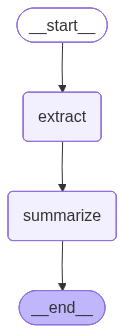

In [52]:
builder.compile()

In [53]:
graph.invoke({
    "text": 
"""A penguin found a shiny laptop buried in the snow.

He pressed one key and accidentally ordered 500 fish online.

The next morning, a giant truck arrived at the iceberg.

Every penguin in town showed up for the feast.

They declared him the "Chief Technology Officer" of Antarctica.

The penguin still has no idea what the Enter key does.
""".strip()
 })

{'text': 'Extracted: A penguin found a shiny laptop buried in the snow.\n\nHe pressed one key and accidentally ordered 500 fish online.\n\nThe next morning, a giant truck arrived at the iceberg.\n\nEvery penguin in town showed up for the feast.\n\nThey declared him the "Chief Technology Officer" of Antarctica.\n\nThe penguin still has no idea what the Enter key does.',
 'summary': 'Summarized: A penguin found a laptop in the snow, accidentally ordered 500 fish, and became the town’s CTO after the whole colony enjoyed the feast. He still doesn’t know what the Enter key does.'}